# Acceptance & Teleport Probability vs N

This notebook is a double-well analog of Figure 5.5 from Lindsey, Weare & Zhang (2022),
not a literal reproduction. The paper's actual Figure 5.5 is computed on the univariate
Gaussian process regression posterior.

Instead, we compute the same two quantities the paper defines, empirical acceptance
probability A and empirical teleport probability T (the probability that the cloned
and removed walker indices differ), as functions of N, on the double-well target already
used in notebooks 03 and 04. This lets us check the same qualitative trend the paper reports
(A and T both increasing toward 1 as N grows) on a target we've already built and validated,
without conflating it with the paper's specific numbers.

**Note on axis scale:** the paper's own Figure 5.5 uses a linear N-axis. We use a log-scale
N-axis here instead, since our chosen N values ([1, 2, 5, 10, 20, 50, 100]) are not evenly
spaced, so a linear axis would crush the small-N detail into a narrow region on the left. This
is a deliberate choice for readability, not an attempt to visually match the paper's figure.

In [1]:
!git clone https://github.com/thunderbolt190/teleport-mcmc.git
%cd teleport-mcmc
!pip install -e ".[dev,benchmarks]" -q

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import os
from teleport.kernels.teleporting import teleporting_walkers_jax
from teleport.targets import log_prob_doublewell

jax.config.update("jax_enable_x64", True)

Cloning into 'teleport-mcmc'...
remote: Enumerating objects: 664, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 664 (delta 55), reused 6 (delta 6), pack-reused 561 (from 1)
Receiving objects: 100% (664/664), 371.24 KiB | 4.17 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/teleport-mcmc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 12.

## Methodology

We use `acceptance_teleport_probs(n_walkers, key)`, which runs the teleporting walkers
algorithm on the double-well target (`teleport.targets.log_prob_doublewell`) and returns:

- **Accepted probability** - `mean(accepts[burnin:])`, the fraction of post-burn-in steps
  where the Metropolis-Hastings proposal was accepted.
- **Teleported probability** - `mean(teleports[burnin:])`, the fraction of post-burn-in
  accepted steps where the cloned index `j` and removed index `i` differ (i.e. `i != j`).
- **Mode coverage** - fraction of post-burn-in samples in the right-hand well, as a
  check that the ensemble isn't stuck in one mode.

**Settings:** `n_steps=5000`, `step_size=0.5`, `burnin=500`, single seed
(`key=jax.random.PRNGKey(42)`) per N.

**N values tested:** `[1, 2, 5, 10, 20, 50, 100]`.

Teleporting
is well-defined at N=1, and the teleport probability is expected to be exactly 0 at N=1
by construction (there's only one walker, so `i == j` always).

In [6]:
def acceptance_teleport_probs(n_walkers, key):
    key1, key2 = jax.random.split(key)
    n_steps = 5000
    step_size = 0.5
    burnin = 500

    walkers = -0.707 + 0.1 * jax.random.normal(key1, shape=(n_walkers, 1))
    final_walkers, chain, accepts, teleports = teleporting_walkers_jax(
        walkers, log_prob_doublewell, step_size, n_steps, key2
    )

    acceptance_prob = jnp.mean(accepts[burnin:])
    teleport_prob = jnp.mean(teleports[burnin:])
    mode_coverage = jnp.mean(chain[burnin:] > 0)
    return float(acceptance_prob), float(teleport_prob), float(mode_coverage)

In [7]:
key = jax.random.PRNGKey(42)
Ns = [1, 2, 5, 10, 20, 50, 100]

accepted_probs = {}
teleported_probs = {}
mode_coverage = {}

for N in Ns:
  a, t, c = acceptance_teleport_probs(N, key)
  accepted_probs[N] = a
  teleported_probs[N] = t
  mode_coverage[N] = c

print(accepted_probs)
print(teleported_probs)
print(mode_coverage)

{1: 0.660444438457489, 2: 0.7080000042915344, 5: 0.8062222599983215, 10: 0.8337777853012085, 20: 0.8617777824401855, 50: 0.8908888697624207, 100: 0.8897777795791626}
{1: 0.0, 2: 0.33888888359069824, 5: 0.7711111307144165, 10: 0.8846666812896729, 20: 0.9497777819633484, 50: 0.9791111350059509, 100: 0.9913333654403687}
{1: 0.5417777895927429, 2: 0.5134444236755371, 5: 0.49337777495384216, 10: 0.49462223052978516, 20: 0.5067444443702698, 50: 0.49326667189598083, 100: 0.5069088935852051}


In [8]:
print("| N | Accepted Probability | Teleported Probability | Mode Coverage |")
print("|---|---|---|---|")
for N in Ns:
  print(f"| {N} | {accepted_probs[N]:.3f} | {teleported_probs[N]:.3f} | {mode_coverage[N]:.3f} |")

| N | Accepted Probability | Teleported Probability | Mode Coverage |
|---|---|---|---|
| 1 | 0.660 | 0.000 | 0.542 |
| 2 | 0.708 | 0.339 | 0.513 |
| 5 | 0.806 | 0.771 | 0.493 |
| 10 | 0.834 | 0.885 | 0.495 |
| 20 | 0.862 | 0.950 | 0.507 |
| 50 | 0.891 | 0.979 | 0.493 |
| 100 | 0.890 | 0.991 | 0.507 |


| N | Accepted Probability | Teleported Probability | Mode Coverage |
|---|---|---|---|
| 1 | 0.660 | 0.000 | 0.542 |
| 2 | 0.708 | 0.339 | 0.513 |
| 5 | 0.806 | 0.771 | 0.493 |
| 10 | 0.834 | 0.885 | 0.495 |
| 20 | 0.862 | 0.950 | 0.507 |
| 50 | 0.891 | 0.979 | 0.493 |
| 100 | 0.890 | 0.991 | 0.507 |

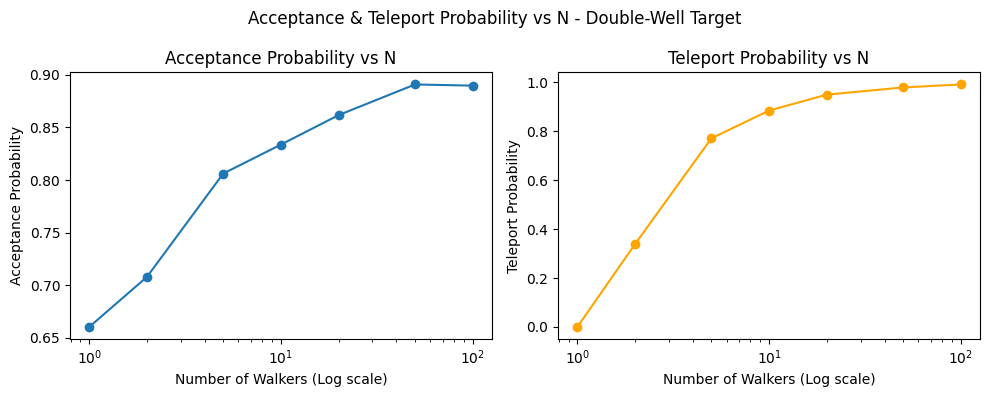

In [9]:
Ns_arr = Ns  # already a list [1,2,5,10,20,50,100]
accept_vals = [accepted_probs[N] for N in Ns]
teleport_vals = [teleported_probs[N] for N in Ns]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(Ns_arr, accept_vals, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Walkers (Log scale)')
axes[0].set_ylabel('Acceptance Probability')
axes[0].set_title('Acceptance Probability vs N')

axes[1].plot(Ns_arr, teleport_vals, marker='o', color='orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Walkers (Log scale)')
axes[1].set_ylabel('Teleport Probability')
axes[1].set_title('Teleport Probability vs N')

plt.suptitle('Acceptance & Teleport Probability vs N - Double-Well Target')
plt.tight_layout()

os.makedirs("benchmarks/results", exist_ok=True)
plt.savefig("benchmarks/results/accept_teleport_vs_n_doublewell.png", dpi=150, bbox_inches='tight')
plt.show()

## Results & Discussion

**Both quantities increase with N.** Acceptance probability
rises from 0.660 (N=1) to 0.890 (N=100), and teleport probability rises
from exactly 0.000 (N=1) to 0.991 (N=100). This qualitatively matches
the trend described in the paper's own Figure 5.5, where both A and T
increase toward 1 as N grows.

**N=1 teleport probability is 0.** With only one
walker, the cloned index and the removed index are always the same
(`i == j`), so teleport probability should be 0.

**Both curves appear to be flattening by N=50–100.** Acceptance
probability barely changes from N=50 (0.891) to N=100 (0.890), and
teleport probability's increase also slows over the same range (0.979
to 0.991). This is consistent with the diminishing-returns pattern
already seen in the IAT-vs-N results in notebook 03, where most of the
benefit from adding walkers on this target seems to be captured well
before N=100.

**Mode coverage stayed close to 0.50 throughout** (range 0.493–0.542
across all N), confirming these acceptance/teleport trends reflect ensemble behavior rather than a stuck
ensemble.

**Note.**
- These are single-seed results (`key=jax.random.PRNGKey(42)`),
unlike notebooks 03/04 which each used 10 seeds per setting.
- This experiment is a double-well analog of
Figure 5.5, not a literal reproduction and the specific values here should not be compared
numerically against the paper's own Figure 5.5, which uses a different
target (the univariate GP regression posterior).